In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import zipfile

zip_path = '/content/drive/MyDrive/Datasets/garbage_classification.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import os

In [17]:
base_dir = '/content/dataset/garbage_classification'
classes = os.listdir(base_dir)
print(classes)

['brown-glass', 'biological', 'green-glass', 'trash', 'battery', 'metal', 'paper', 'clothes', 'shoes', 'cardboard', 'white-glass', 'plastic']


In [18]:
total_images = 0
for cls in classes:
    path = os.path.join(base_dir, cls)
    count = len(os.listdir(path))
    print(f'{cls}: {count}')
    total_images += count

print('Total Images:', total_images)

brown-glass: 607
biological: 985
green-glass: 629
trash: 697
battery: 945
metal: 769
paper: 1050
clothes: 5325
shoes: 1977
cardboard: 891
white-glass: 775
plastic: 865
Total Images: 15515


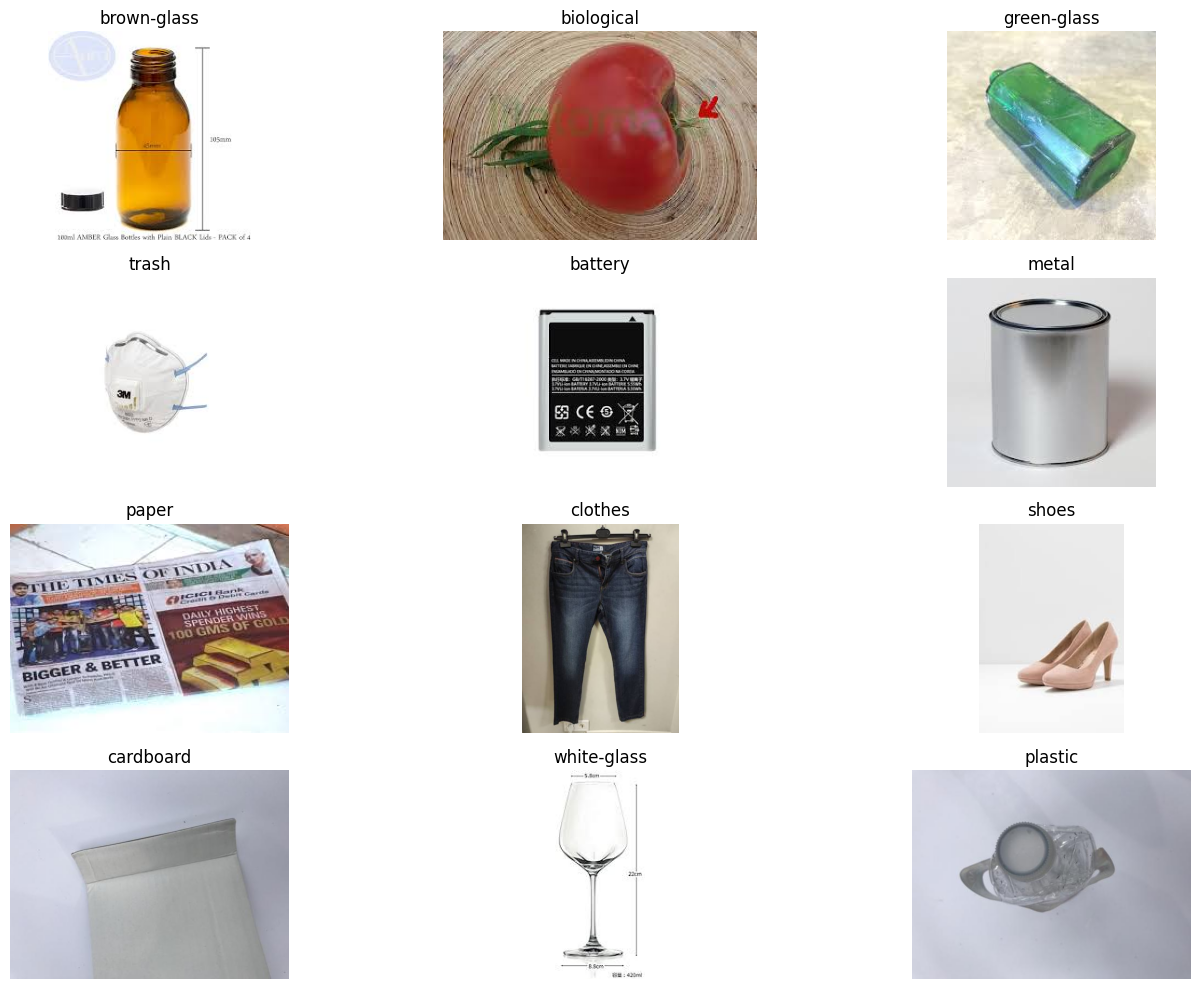

In [19]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    img_path = os.path.join(base_dir, cls, os.listdir(os.path.join(base_dir, cls))[0])
    img = plt.imread(img_path)

    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset= 'training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [22]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [23]:
print(train_generator.class_indices)
print(class_weights)

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
{0: np.float64(1.3684964726631392), 1: np.float64(1.3129230118443316), 2: np.float64(2.128772290809328), 3: np.float64(1.451028517999065), 4: np.float64(0.24285993740219092), 5: np.float64(2.052744708994709), 6: np.float64(1.6795183982683983), 7: np.float64(1.2316468253968254), 8: np.float64(1.4950626204238922), 9: np.float64(0.6539717656974294), 10: np.float64(1.8540919952210275), 11: np.float64(1.6686827956989247)}


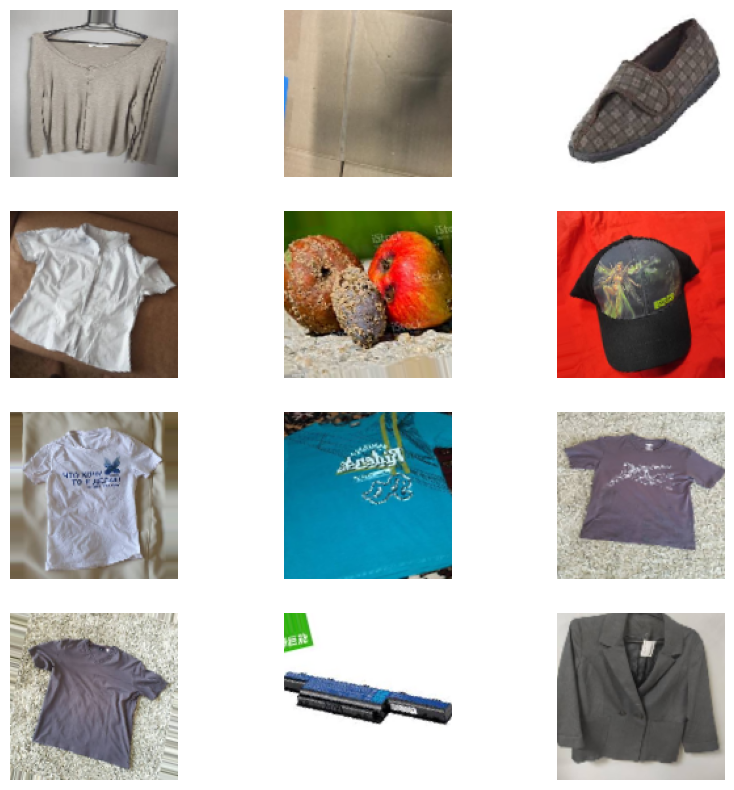

In [24]:
sample_images, _ = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(12):
    plt.subplot(4,3,i+1)
    plt.imshow(sample_images[i])
    plt.axis('off')

plt.show()

In [25]:
baseline_model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(len(classes), activation='softmax')
])

In [26]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,964 (25.02 MB)

 Trainable params: 6,557,964 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 85s 203ms/step - accuracy: 0.5160 - loss: 1.4694 - val_accuracy: 0.5671 - val_loss: 1.2980
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 72s 186ms/step - accuracy: 0.6467 - loss: 1.0623 - val_accuracy: 0.6226 - val_loss: 1.1417
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 70s 181ms/step - accuracy: 0.6988 - loss: 0.9178 - val_accuracy: 0.6581 - val_loss: 1.0243
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 183ms/step - accuracy: 0.7248 - loss: 0.8381 - val_accuracy: 0.6729 - val_loss: 1.0117
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 70s 182ms/step - accuracy: 0.7478 - loss: 0.7685 - val_accuracy: 0.6810 - val_loss: 0.9740
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.7682 - loss: 0.7112 - val_accuracy: 0.6910 - val_loss: 0.9690
Epoch 7/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 183ms/step - accuracy: 0.7855 - loss: 0.6506 - val_accuracy: 0.7268 - val_loss: 0.8589
Epoch 8/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.7952 - loss: 0

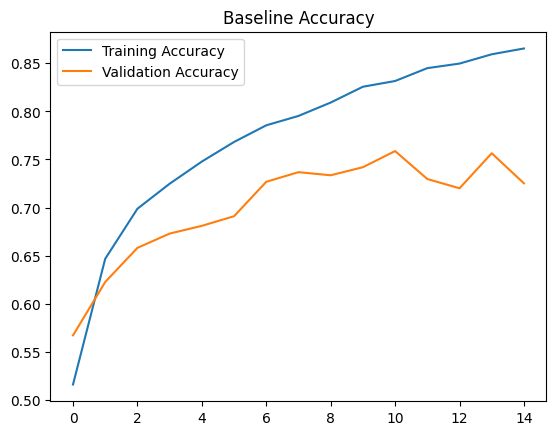

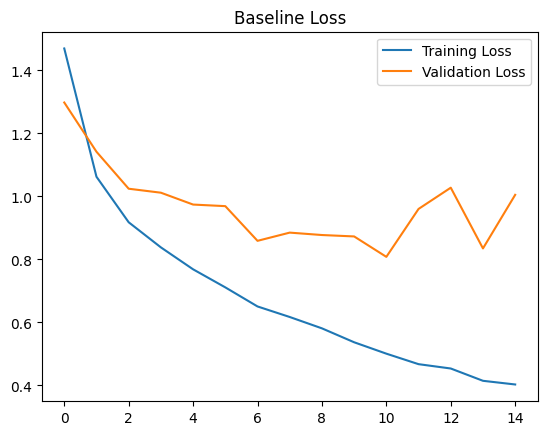

In [28]:
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Baseline Accuracy')
plt.show()

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Baseline Loss')
plt.show()

In [29]:
loss, accuracy = baseline_model.evaluate(val_generator)
print('Validation Accuracy:', accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7252 - loss: 1.0049
Validation Accuracy: 0.7251613140106201


In [30]:
predictions = baseline_model.predict(val_generator)
pred_classes = np.argmax(predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_labels))

97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step
              precision    recall  f1-score   support

     battery       0.44      0.83      0.58       189
  biological       0.78      0.63      0.70       197
 brown-glass       0.89      0.60      0.71       121
   cardboard       0.81      0.70      0.75       178
     clothes       0.89      0.93      0.91      1065
 green-glass       0.95      0.58      0.72       125
       metal       0.35      0.42      0.38       153
       paper       0.63      0.73      0.68       210
     plastic       0.59      0.66      0.62       173
       shoes       0.74      0.61      0.66       395
       trash       0.77      0.58      0.66       139
 white-glass       0.49      0.34      0.40       155

    accuracy                           0.73      3100
   macro avg       0.69      0.63      0.65      3100
weighted avg       0.75      0.73      0.73      3100



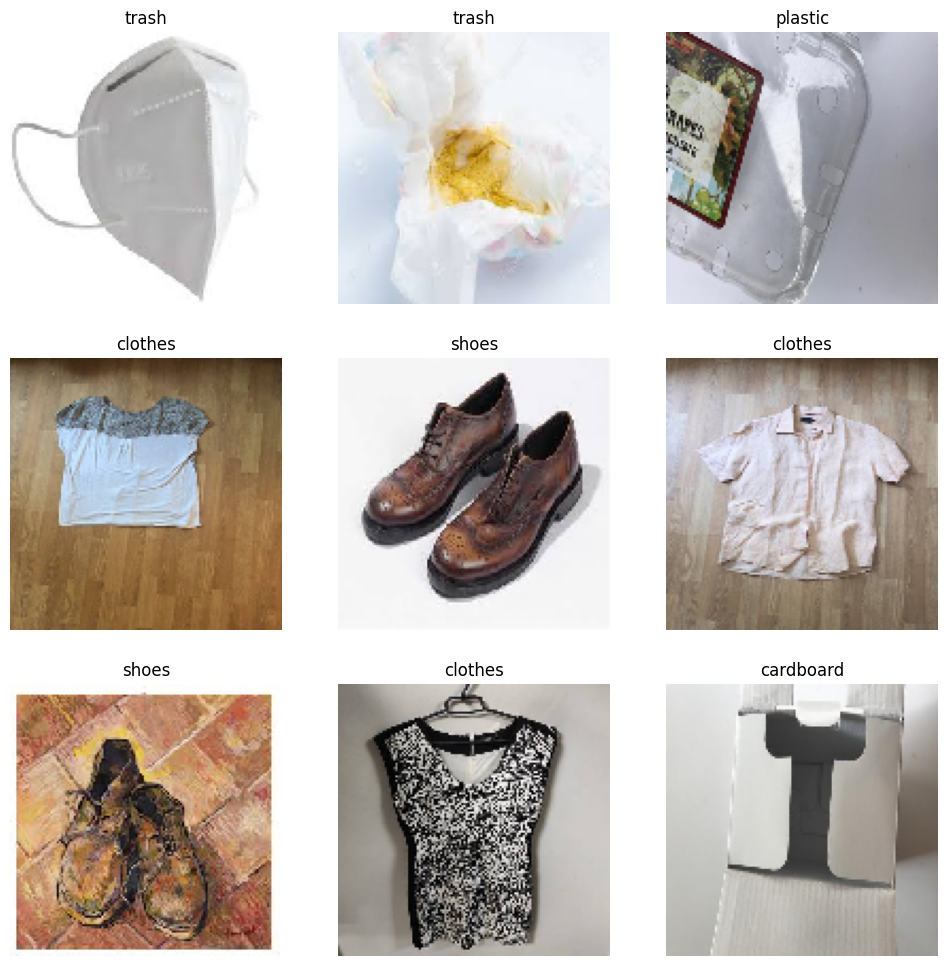

In [31]:
images = []
labels = []

for i in range(len(val_generator)):
    x, y = val_generator[i]
    images.append(x)
    labels.append(y)

images = np.concatenate(images)
labels = np.concatenate(labels)

random_idx = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(12,12))

for i, j in enumerate(random_idx):
    plt.subplot(3,3,i+1)
    plt.imshow(images[j])
    plt.title(class_labels[np.argmax(labels[j])])
    plt.axis('off')

plt.show()

In [32]:
deeper_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 90s 205ms/step - accuracy: 0.4255 - loss: 1.8580 - val_accuracy: 0.3297 - val_loss: 2.0134
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.5335 - loss: 1.4468 - val_accuracy: 0.5961 - val_loss: 1.2346
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.5771 - loss: 1.2997 - val_accuracy: 0.6226 - val_loss: 1.1883
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 79s 202ms/step - accuracy: 0.6115 - loss: 1.1986 - val_accuracy: 0.6490 - val_loss: 1.0857
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 73s 188ms/step - accuracy: 0.6402 - loss: 1.1131 - val_accuracy: 0.6181 - val_loss: 1.1200
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.6613 - loss: 1.0504 - val_accuracy: 0.6539 - val_loss: 1.0269
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 72s 184ms/step - accuracy: 0.6802 - loss: 1.0042 - val_accuracy: 0.6368 - val_loss: 1.1072
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 182ms/step - accuracy: 0.6938 - loss: 0

In [34]:
sgd_model = tf.keras.models.clone_model(deeper_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 81s 194ms/step - accuracy: 0.3406 - loss: 2.2700 - val_accuracy: 0.3797 - val_loss: 1.8297
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 183ms/step - accuracy: 0.4475 - loss: 1.7592 - val_accuracy: 0.5339 - val_loss: 1.5222
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 182ms/step - accuracy: 0.4892 - loss: 1.6001 - val_accuracy: 0.5448 - val_loss: 1.4094
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.5185 - loss: 1.4945 - val_accuracy: 0.6032 - val_loss: 1.2898
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 71s 183ms/step - accuracy: 0.5366 - loss: 1.4336 - val_accuracy: 0.5774 - val_loss: 1.2751
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 69s 179ms/step - accuracy: 0.5557 - loss: 1.3646 - val_accuracy: 0.5587 - val_loss: 1.3270
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 69s 179ms/step - accuracy: 0.5710 - loss: 1.3328 - val_accuracy: 0.6203 - val_loss: 1.1719
Epoch 8/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - accuracy: 0.5834 - loss: 1

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable = False

In [37]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

In [38]:
train_generator_transfer = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_transfer = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [39]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=10
)

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 210s 496ms/step - accuracy: 0.5956 - loss: 1.3384 - val_accuracy: 0.8039 - val_loss: 0.6956
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 161s 415ms/step - accuracy: 0.7888 - loss: 0.7004 - val_accuracy: 0.8642 - val_loss: 0.4850
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 159s 411ms/step - accuracy: 0.8450 - loss: 0.5226 - val_accuracy: 0.8768 - val_loss: 0.4103
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 169s 435ms/step - accuracy: 0.8663 - loss: 0.4495 - val_accuracy: 0.8868 - val_loss: 0.3778
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 166s 428ms/step - accuracy: 0.8845 - loss: 0.3848 - val_accuracy: 0.8913 - val_loss: 0.3385
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 163s 421ms/step - accuracy: 0.8884 - loss: 0.3653 - val_accuracy: 0.8932 - val_loss: 0.3247
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 166s 428ms/step - accuracy: 0.8961 - loss: 0.3434 - val_accuracy: 0.8961 - val_loss: 0.3194
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 167s 430ms/step - accuracy: 0.9052 -

In [40]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [41]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
history_finetune = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=5
)

Epoch 1/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 196s 463ms/step - accuracy: 0.8596 - loss: 0.4421 - val_accuracy: 0.9010 - val_loss: 0.2836
Epoch 2/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 163s 420ms/step - accuracy: 0.8946 - loss: 0.3425 - val_accuracy: 0.9090 - val_loss: 0.2650
Epoch 3/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 164s 422ms/step - accuracy: 0.9048 - loss: 0.3013 - val_accuracy: 0.9100 - val_loss: 0.2569
Epoch 4/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 170s 439ms/step - accuracy: 0.9122 - loss: 0.2766 - val_accuracy: 0.9119 - val_loss: 0.2509
Epoch 5/5
388/388 ━━━━━━━━━━━━━━━━━━━━ 164s 424ms/step - accuracy: 0.9157 - loss: 0.2611 - val_accuracy: 0.9106 - val_loss: 0.2509
